In [28]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import os
from cmcrameri import cm
from cartopy import crs as ccrs
from cartopy.feature import LAND

ease2_N = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=90)
ease2_S = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=-90)
pc = ccrs.PlateCarree()

In [19]:
def get_date_range_in_str(start_str, end_str):

    """
    takes two strings of dates in the format "yyyymmdd" and returns a list of all dates in between in the same format
    """

    from datetime import datetime, timedelta
    
    # Parse input strings into datetime objects
    start_date = datetime.strptime(start_str, "%Y%m%d")
    end_date = datetime.strptime(end_str, "%Y%m%d")
    
    # Compute number of days between dates
    num_days = (end_date - start_date).days + 1  # +1 to include end date
    
    # Generate list of date strings
    date_list = [
        (start_date + timedelta(days=i)).strftime("%Y%m%d")
        for i in range(num_days)
    ]
    return date_list

#### read and display dataset for single day and hemisphere

In [13]:
date = '20190110'
hemis = 'N'
vfv = 'v01_fv02'
ds = xr.open_dataset(f'/mnt/web/data/IceAge_RRDP/Snapshot/{vfv}/{date}_{hemis}_{vfv}.nc', 
                     mask_and_scale=False)

ds

<xarray.Dataset> Size: 12MB
Dimensions:                    (time: 1, yc: 240, xc: 240)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2019-01-10T12:00:00
  * xc                         (xc) float64 2kB -2.988e+06 ... 2.988e+06
  * yc                         (yc) float64 2kB 2.988e+06 ... -2.988e+06
Data variables: (12/57)
    icetype_matches            (time, yc, xc) int16 115kB ...
    myi_concentration_matches  (time, yc, xc) float32 230kB ...
    NIC_dom_icetype            (time, yc, xc) int8 58kB ...
    NIC_dom_icetype_conc       (time, yc, xc) float32 230kB ...
    NIC_myi_conc               (time, yc, xc) float32 230kB ...
    NIC_total_ice_conc         (time, yc, xc) float32 230kB ...
    ...                         ...
    ERA5_v10_min               (time, yc, xc) float32 230kB ...
    ERA5_v10_max               (time, yc, xc) float32 230kB ...
    ERA5_v10_mean              (time, yc, xc) float32 230kB ...
    ASCAT_S0                   (time, yc, xc) float32 230kB ...
    crs                        int32 4B ...
    OSISAF_sic                 (time, xc, yc) float32 230kB ...
Attributes:
    title:              Round Robin Data Package for Sea Ice Types
    summary:            Multi-source sea ice type classification product grid...
    date_created:       2026-02-16T12:03:45Z
    date:               20190110
    hemisphere:         N
    resolution_m:       25000
    projection:         +proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WG...
    datasets_included:  NIC, autoDMI
    Conventions:        CF-1.8
    ice_type_codes:     1=YI (Young Ice), 2=FYI (First-Year Ice), 3=SYI (Seco...

#### read and display dataset for multiple days

In [8]:
# read dataset for multiple days within date range
start_date = '20220101'
end_date = '20220110'
hemis = 'N'
date_list = get_date_range_in_str(start_date, end_date)

# Open all datasets in the date range, skipping missing files
available_files = [f'/mnt/spaces/Users/hniehaus/SAGE/RRDP/output/S/netcdfs/{date[:4]}/{date}_{hemis}.nc' 
                   for date in date_list 
                   if os.path.exists(f'/mnt/spaces/Users/hniehaus/SAGE/RRDP/output/S/netcdfs/{date[:4]}/{date}_{hemis}.nc')]

ds2 = xr.open_mfdataset(
    available_files,
    combine='by_coords',
    join='outer',
    compat='override',
    coords='minimal',
    data_vars='minimal',
    mask_and_scale=False
)

ds2

OSError: no files to open

#### display pure icetype and myi concentration matches for single day

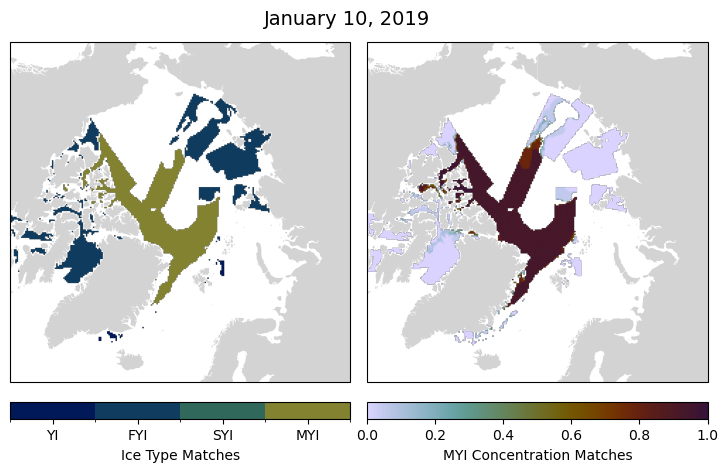

In [81]:
from matplotlib.colors import BoundaryNorm, ListedColormap

# Determine projection based on hemisphere
ease2 = ease2_N if hemis == 'N' else ease2_S

# Get the x and y coordinates from the dataset to set proper extent
x_coords = ds['xc'].values
y_coords = ds['yc'].values
extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]

# Create colormap for ice types (FYI, SYI, MYI) - indices 2, 3, 4
n_wmo = 4
wmo_positions = [0, 0.1, 0.3, 0.5]  # For indices 2-4 (FYI, SYI, MYI)
wmo_colors = [cm.batlow(pos) for pos in wmo_positions]
wmo_cmap = ListedColormap(wmo_colors)
wmo_bounds = np.arange(0.5, n_wmo + 1, 1)  # Starts at 1.5 (between 1 and 2)
wmo_norm = BoundaryNorm(wmo_bounds, wmo_cmap.N)

# Format the date nicely
date_str = ds.attrs['date']
date_obj = datetime.strptime(date_str, '%Y%m%d')
formatted_date = date_obj.strftime('%B %d, %Y')

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': ease2}, figsize=(9, 5))

# Plot icetype_matches (data is already in EASE-2 coordinates, no transform needed)
im1 = axes[0].imshow(ds['icetype_matches'][0,:,:], cmap=wmo_cmap, norm=wmo_norm, 
                     origin='upper', extent=extent)
im1.cmap.set_under(alpha=0)

# Plot myi_concentration_matches
im2 = axes[1].imshow(ds['myi_concentration_matches'][0,:,:], vmin=0, vmax=1, cmap=cm.glasgow_r,
                     origin='upper', extent=extent)

# Add land features and set extent
for ax in axes:
    ax.add_feature(LAND, facecolor='lightgray', zorder=2)
    ext_lim = 3000000 if hemis == 'N' else 4200000
    ax.set_extent([-ext_lim, ext_lim, -ext_lim, ext_lim], crs=ease2)

# Adjust spacing before adding colorbars
plt.subplots_adjust(wspace=0.05)

# Add colorbars below each plot with aspect control
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='horizontal', pad=0.05, fraction=0.046, aspect=20, label=f'Ice Type Matches')
cbar1.set_ticks([1, 2, 3, 4])
cbar1.set_ticklabels(['YI', 'FYI', 'SYI', 'MYI'])
plt.colorbar(im2, ax=axes[1], orientation='horizontal', pad=0.05, fraction=0.046, aspect=20, label='MYI Concentration Matches')
fig.suptitle(formatted_date, fontsize=14, y=0.93)

fig.savefig(f'/home/h_niehaus/Downloads/ice_type_myi_matches_{date}_{hemis}.png', dpi=300, bbox_inches='tight')
plt.show()

#### display data of single dataset: dominant icetype, its concentration, myi concentration, total sea ice concentration

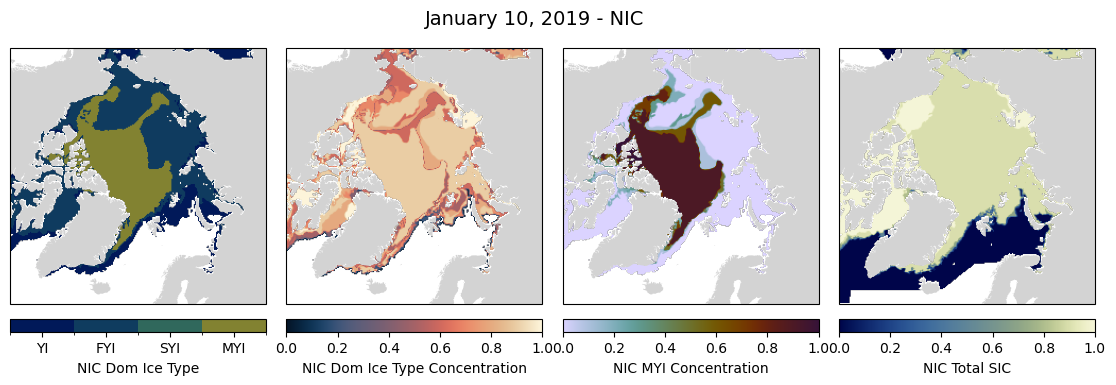

In [83]:
dataset = 'NIC'

# Determine projection based on hemisphere
ease2 = ease2_N if hemis == 'N' else ease2_S

# Get the x and y coordinates from the dataset to set proper extent
x_coords = ds['xc'].values
y_coords = ds['yc'].values
extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]

# Create colormap for ice types (YI, FYI, SYI, MYI) - indices 1-4
n_wmo = 4
wmo_positions = [0, 0.1, 0.3, 0.5]
wmo_colors = [cm.batlow(pos) for pos in wmo_positions]
wmo_cmap = ListedColormap(wmo_colors)
wmo_bounds = np.arange(0.5, n_wmo + 1, 1)
wmo_norm = BoundaryNorm(wmo_bounds, wmo_cmap.N)

# Create truncated davos colormap (use 0-0.9 range for 0-1.0 data)
from matplotlib.colors import LinearSegmentedColormap
davos_truncated = LinearSegmentedColormap.from_list(
    'davos_truncated',
    [cm.davos(i) for i in np.linspace(0, 0.9, 256)]
)

# Format the date nicely
date_str = ds.attrs['date']
date_obj = datetime.strptime(date_str, '%Y%m%d')
formatted_date = date_obj.strftime('%B %d, %Y')

# Check if total_ice_conc exists for this dataset
has_total_conc = f'{dataset}_total_ice_conc' in ds

# Create figure with appropriate number of subplots
num_plots = 4 if has_total_conc else 3
fig, axes = plt.subplots(1, num_plots, subplot_kw={'projection': ease2}, 
                        figsize=(14 if has_total_conc else 10.5, 4))

# Mask where concentration is valid
dom_icetype_masked = np.where(ds[f'{dataset}_dom_icetype_conc'][0,:,:]>=0.0, 
                               ds[f'{dataset}_dom_icetype'][0,:,:], np.nan)

# Plot dom_icetype
im1 = axes[0].imshow(dom_icetype_masked, cmap=wmo_cmap, norm=wmo_norm, 
                     origin='upper', extent=extent)
im1.cmap.set_under(alpha=0)

# Plot dom_icetype_conc
im2 = axes[1].imshow(ds[f'{dataset}_dom_icetype_conc'][0,:,:], vmin=0, vmax=1, 
                     cmap=cm.lipari, origin='upper', extent=extent)

# Plot myi_conc
im3 = axes[2].imshow(ds[f'{dataset}_myi_conc'][0,:,:], vmin=0, vmax=1, 
                     cmap=cm.glasgow_r, origin='upper', extent=extent)

# Plot total_conc if it exists
if has_total_conc:
    im4 = axes[3].imshow(ds[f'{dataset}_total_ice_conc'][0,:,:], vmin=0, vmax=1, 
                         cmap=davos_truncated, origin='upper', extent=extent)

# Add land features and set extent for all axes
for ax in axes:
    ax.add_feature(LAND, facecolor='lightgray', zorder=2)
    ext_lim = 3000000 if hemis == 'N' else 4200000
    ax.set_extent([-ext_lim, ext_lim, -ext_lim, ext_lim], crs=ease2)

# Adjust spacing before adding colorbars
plt.subplots_adjust(wspace=0.08)

# Add colorbars below each plot with aspect control
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='horizontal', pad=0.05, 
                     fraction=0.046, aspect=20, label=f'{dataset} Dom Ice Type')
cbar1.set_ticks([1, 2, 3, 4])
cbar1.set_ticklabels(['YI', 'FYI', 'SYI', 'MYI'])

plt.colorbar(im2, ax=axes[1], orientation='horizontal', pad=0.05, 
            fraction=0.046, aspect=20, label=f'{dataset} Dom Ice Type Concentration')

plt.colorbar(im3, ax=axes[2], orientation='horizontal', pad=0.05, 
            fraction=0.046, aspect=20, label=f'{dataset} MYI Concentration')

if has_total_conc:
    plt.colorbar(im4, ax=axes[3], orientation='horizontal', pad=0.05, 
                fraction=0.046, aspect=20, label=f'{dataset} Total SIC')

fig.suptitle(f'{formatted_date} - {dataset}', fontsize=14, y=0.92)
fig.savefig(f'/home/h_niehaus/Downloads/{dataset}_snapshot_{date}_{hemis}.png', dpi=300, bbox_inches='tight')
plt.show()

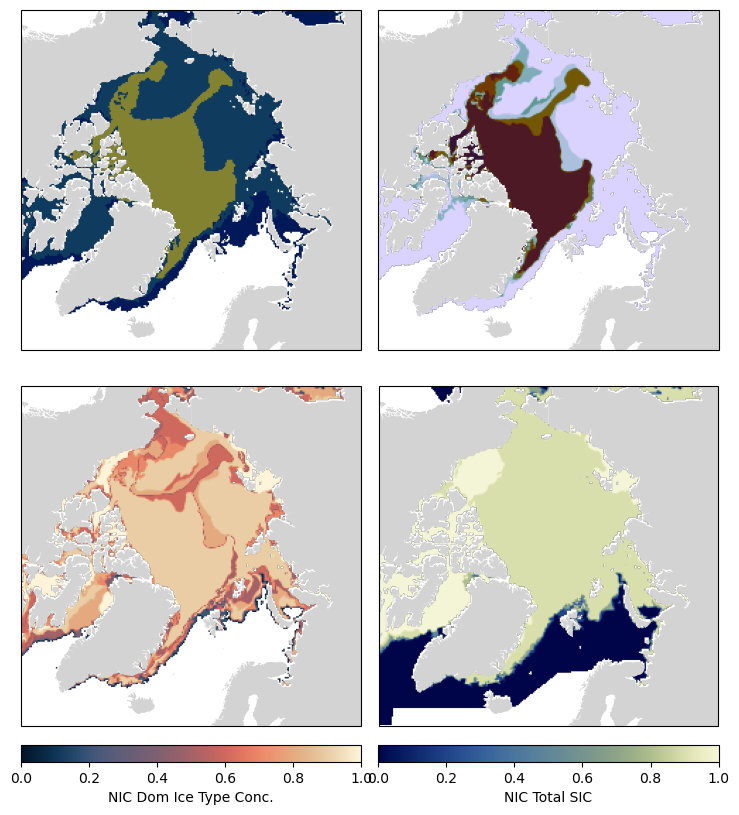

In [79]:
dataset = 'NIC'

# Determine projection based on hemisphere
ease2 = ease2_N if hemis == 'N' else ease2_S

# Get the x and y coordinates from the dataset to set proper extent
x_coords = ds['xc'].values
y_coords = ds['yc'].values
extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]

# Create colormap for ice types (YI, FYI, SYI, MYI) - indices 1-4
n_wmo = 4
wmo_positions = [0, 0.1, 0.3, 0.5]
wmo_colors = [cm.batlow(pos) for pos in wmo_positions]
wmo_cmap = ListedColormap(wmo_colors)
wmo_bounds = np.arange(0.5, n_wmo + 1, 1)
wmo_norm = BoundaryNorm(wmo_bounds, wmo_cmap.N)

# Create truncated davos colormap (use 0-0.9 range for 0-1.0 data)
from matplotlib.colors import LinearSegmentedColormap
davos_truncated = LinearSegmentedColormap.from_list(
    'davos_truncated',
    [cm.davos(i) for i in np.linspace(0, 0.9, 256)]
)

# Format the date nicely
date_str = ds.attrs['date']
date_obj = datetime.strptime(date_str, '%Y%m%d')
formatted_date = date_obj.strftime('%B %d, %Y')

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': ease2}, figsize=(9, 10))

# Mask where concentration is valid
dom_icetype_masked = np.where(ds[f'{dataset}_dom_icetype_conc'][0,:,:]>=0.0, 
                               ds[f'{dataset}_dom_icetype'][0,:,:], np.nan)

# Upper left: Dom ice type
im1 = axes[0, 0].imshow(dom_icetype_masked, cmap=wmo_cmap, norm=wmo_norm, 
                        origin='upper', extent=extent)
im1.cmap.set_under(alpha=0)

# Lower left: Dom ice type concentration
im2 = axes[1, 0].imshow(ds[f'{dataset}_dom_icetype_conc'][0,:,:], vmin=0, vmax=1, 
                        cmap=cm.lipari, origin='upper', extent=extent)

# Upper right: MYI concentration
im3 = axes[0, 1].imshow(ds[f'{dataset}_myi_conc'][0,:,:], vmin=0, vmax=1, 
                        cmap=cm.glasgow_r, origin='upper', extent=extent)

# Lower right: Total SIC (if available)
if f'{dataset}_total_ice_conc' in ds:
    im4 = axes[1, 1].imshow(ds[f'{dataset}_total_ice_conc'][0,:,:], vmin=0, vmax=1, 
                            cmap=davos_truncated, origin='upper', extent=extent)

# Add land features and set extent for all axes
for ax_row in axes:
    for ax in ax_row:
        ax.add_feature(LAND, facecolor='lightgray', zorder=2)
        ext_lim = 3000000 if hemis == 'N' else 4200000
        ax.set_extent([-ext_lim, ext_lim, -ext_lim, ext_lim], crs=ease2)

# Adjust spacing
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Add colorbars
#cbar1 = plt.colorbar(im1, ax=axes[0, 0], orientation='horizontal', pad=0.05, 
#                     fraction=0.046, aspect=20, label=f'{dataset} Dom Ice Type')
#cbar1.set_ticks([1, 2, 3, 4])
#cbar1.set_ticklabels(['YI', 'FYI', 'SYI', 'MYI'])

plt.colorbar(im2, ax=axes[1, 0], orientation='horizontal', pad=0.05, 
            fraction=0.046, aspect=20, label=f'{dataset} Dom Ice Type Conc.')

#plt.colorbar(im3, ax=axes[0, 1], orientation='horizontal', pad=0.05, 
#            fraction=0.046, aspect=20, label=f'{dataset} MYI Concentration')

if f'{dataset}_total_ice_conc' in ds:
    plt.colorbar(im4, ax=axes[1, 1], orientation='horizontal', pad=0.05, 
                fraction=0.046, aspect=20, label=f'{dataset} Total SIC')

#fig.suptitle(f'{formatted_date} - {dataset}', fontsize=14, y=0.93)
fig.savefig(f'/home/h_niehaus/Downloads/{dataset}_snapshot_{date}_{hemis}.png', dpi=300, bbox_inches='tight')
plt.show()

#### functions to experiment with thresholds for matches

In [60]:
def get_match_array(data_dict_25km, threshold=1e-5):
    """
    Computes a consensus ice type array from multiple datasets by identifying pixels where the dominant ice type agrees across datasets.
    For each pixel, the function:
    - Filters out low-confidence or missing data (dominant concentration < 0.8 or value == -77).
    - Stacks the dominant ice type arrays from all datasets.
    - Calculates the standard deviation and mean of the dominant ice type at each pixel, ignoring NaNs.
    - Identifies pixels where at least two datasets agree (standard deviation <= threshold and at least 2 valid values).
    - Assigns the rounded mean ice type value to those pixels; otherwise, assigns -77.
    Parameters
    ----------
    data_dict_25km : dict
        Dictionary where each value is a dict containing:
            - 'dom_icetype': 2D numpy array of dominant ice type codes.
            - 'dom_icetype_conc': 2D numpy array of dominant ice type concentrations.
    threshold : float, optional
        Maximum allowed standard deviation for agreement (default is 1e-5).
    Returns
    -------
    match_value : numpy.ndarray
        2D array of consensus ice type values (int16), with -77 indicating no agreement or insufficient data.
    """
    import numpy as np
    
    # For matching, use concentrations of dominant icetypes to filter for dominant ice types with very high (>=90%) concentrations
    icetype_arrays = []
    for value in data_dict_25km.values():
        dominant_concentration = value['dom_icetype_conc']
        dominant_icetype = value['dom_icetype'].copy().astype(np.float32)
        dominant_icetype[dominant_icetype == -77] = np.nan
        # Use NaN instead of -77 for missing/low confidence data
        dominant_icetype[dominant_concentration < 0.8] = -77
        icetype_arrays.append(dominant_icetype)
    
    # Stack filtered arrays
    icetype_arr = np.stack(icetype_arrays, axis=0)  # Shape: (n_datasets, height, width)
    
    # Calculate std across datasets (ignoring NaN)
    # Where std is ~0, all valid values agree
    with np.errstate(invalid='ignore'):  # Suppress NaN warnings
        std_vals = np.nanstd(icetype_arr, axis=0)
        mean_vals = np.nanmean(icetype_arr, axis=0)
    
    # Count valid (non-NaN) values per pixel
    n_valid = (~np.isnan(icetype_arr)).sum(axis=0)
    
    # Agreement where: std is ~0 and at least 2 valid values
    match_yes = (std_vals <= threshold) & (n_valid >= 2)
    
    # Initialize output array
    match_value = np.full(icetype_arr.shape[1:], -77, dtype=np.int16)
    
    # Store mean value where there's agreement (round to nearest int for ice types)
    match_value[match_yes] = np.round(mean_vals[match_yes]).astype(np.int16)
    
    return match_value


def get_match_array_myi_concentration(data_dict_25km, threshold=0.2):
    """
    Find grid cells where MYI concentration values agree across multiple datasets.
    Vectorized for better performance.
    
    Parameters
    ----------
    data_dict_25km : dict
        Dictionary where keys are dataset names and values are dicts containing
        'myi_conc' arrays with MYI concentration values (0.0 to 1.0 or NaN)
    threshold : float
        Maximum allowed difference between MYI concentrations for agreement (default: 0.1)
        
    Returns
    -------
    match_array : 2D np.ndarray
        Array with mean MYI concentration values where datasets agree, NaN elsewhere
    """
    import numpy as np
    
    # Get all myi_conc arrays
    myi_arrays = []
    
    for value in data_dict_25km.values():
        myi_concentration = value['myi_conc'].copy()
        #myi_concentration[(myi_concentration >= 0.9) | (myi_concentration <= 0.1)] = np.nan
        myi_arrays.append(myi_concentration)
    
    if len(myi_arrays) < 2:
        print(f"Need at least 2 datasets with myi_conc, found {len(myi_arrays)}")
        return np.full_like(myi_arrays[0], np.nan) if len(myi_arrays) > 0 else None
    
    # Stack arrays along new axis
    stacked = np.stack(myi_arrays, axis=0)  # Shape: (n_datasets, height, width)
    
    # Calculate mean across datasets (ignoring NaN)
    mean_myi_conc = np.nanmean(stacked, axis=0)
    
    # For each pixel, check if all finite values are within ±threshold of the mean
    abs_diff = np.abs(stacked - mean_myi_conc)
    # Mask for finite values
    finite_mask = np.isfinite(stacked)
    # For each pixel, check if all finite values are within threshold
    all_within = np.all((abs_diff <= threshold) | ~finite_mask, axis=0)
    # Also require at least 2 finite values
    n_finite = np.sum(finite_mask, axis=0)
    final_mask = (all_within & (n_finite >= 2))
    
    # Create output array
    match_array = np.full(stacked.shape[1:], np.nan, dtype=np.float32)
    match_array[final_mask] = mean_myi_conc[final_mask]
    
    return np.round(match_array, 2)

In [61]:
# restructure the output data from the -nc file to the structure needed for the matching functions
# get dataset names from the datasets_included attribute
datasets = ds.attrs['datasets_included'].split(', ')

# create dictionary with ice type data from the dataset
data_dict = {}
for dataset in datasets:
    data_dict[dataset] = {
    'dom_icetype': ds[f'{dataset}_dom_icetype'][0, :, :].values.filled(-77) if hasattr(ds[f'{dataset}_dom_icetype'][0, :, :].values, 'filled') else ds[f'{dataset}_dom_icetype'][0, :, :].values,
    'dom_icetype_conc': ds[f'{dataset}_dom_icetype_conc'][0, :, :].values,
    'myi_conc': ds[f'{dataset}_myi_conc'][0, :, :].values
}

In [62]:
dom_icetype_match = get_match_array(data_dict)
myi_conc_match = get_match_array_myi_concentration(data_dict)

/home/h_niehaus/.local/share/mamba/envs/gen/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_818195/1548581357.py:42: RuntimeWarning: Mean of empty slice
  mean_vals = np.nanmean(icetype_arr, axis=0)
/tmp/ipykernel_818195/1548581357.py:95: RuntimeWarning: Mean of empty slice
  mean_myi_conc = np.nanmean(stacked, axis=0)


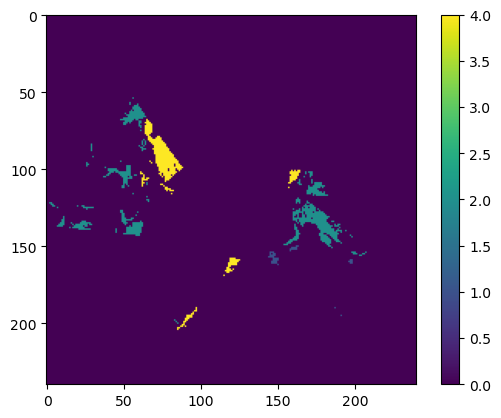

In [63]:
plt.imshow(dom_icetype_match, vmin=0, cmap='viridis')
plt.colorbar()

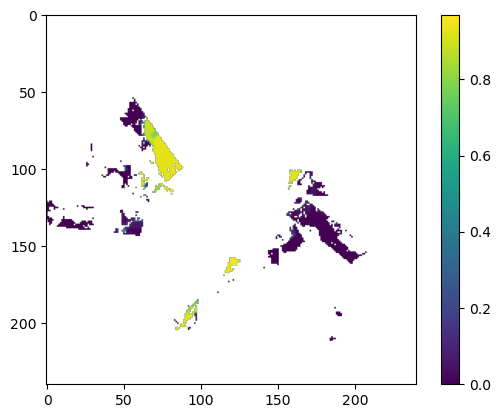

In [64]:
plt.imshow(myi_conc_match, vmin=0, cmap='viridis')
plt.colorbar()